In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#data loading
data = pd.read_csv("cleaned_file2.csv")
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['score'] = data['score'].round(1)
data['attendance'] = data['attendance'].replace({'(?i)unknown': 'Absent'}, regex=True)
data = data[~data['subject'].str.contains(r'(?i)^unknown$', na=False)]
data = data[~data['name'].str.contains(r'(?i)^unknown$', na=False)]

# Optional: Standardize case for consistency
data['attendance'] = data['attendance'].str.capitalize()
data['categorize_performance'] = data['categorize_performance'].str.capitalize()

In [ ]:
# Ensure 'date' column is datetime
data['date'] = pd.to_datetime(data['date'], errors='coerce')

# Extract month and year for time-based analysis
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['year_month'] = data['date'].dt.to_period('M')  # e.g., 2023-09

# Optional: Create score bins if categorize_performance wasn't reliable
# But since it's already provided, you can trust it.

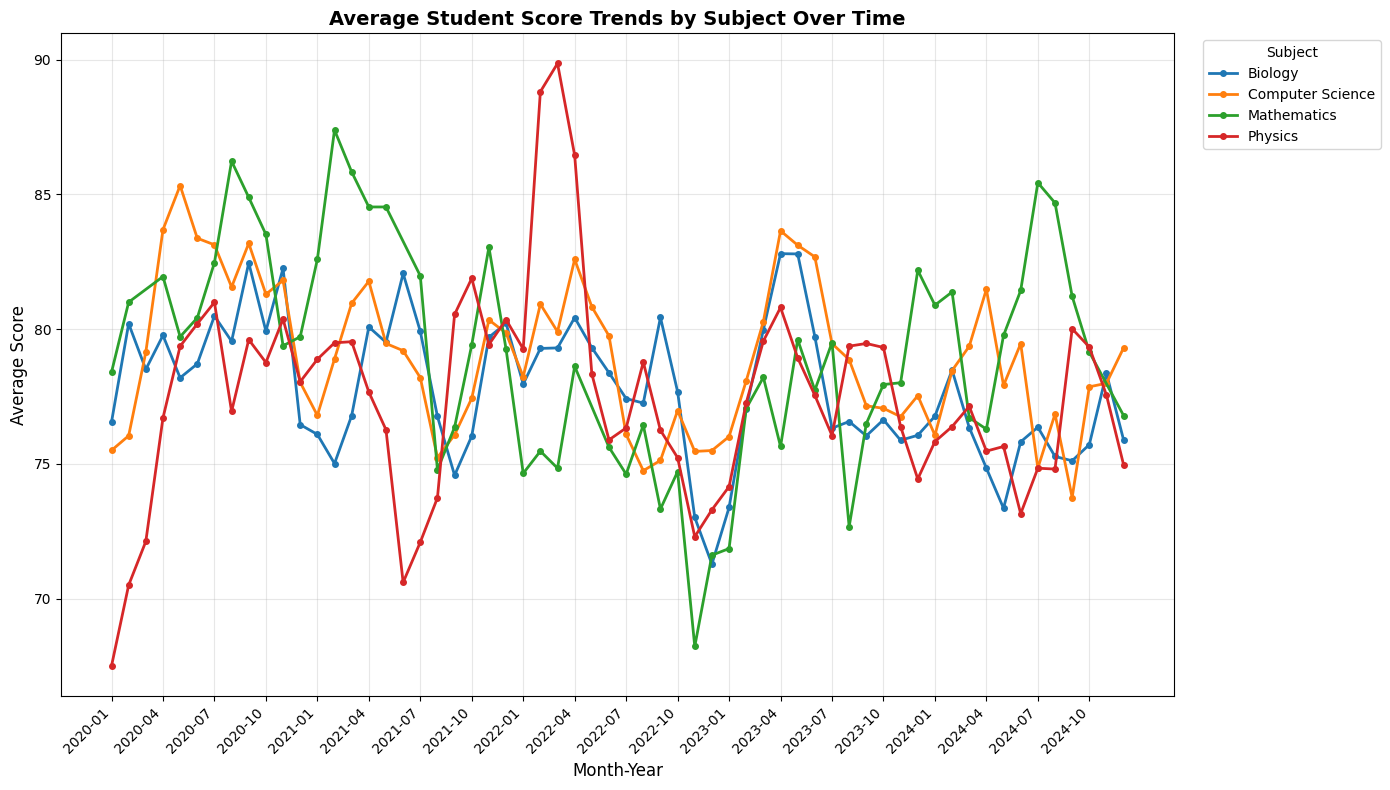

In [3]:
# Assuming 'data' is your DataFrame...

avg_scores = data.groupby(['subject', 'year_month'])['score'].mean().reset_index()
avg_scores['smoothed_score'] = avg_scores.groupby('subject')['score'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Ensure year_month is sorted (optional but safe)
avg_scores = avg_scores.sort_values('year_month')

plt.figure(figsize=(14, 8))

colors = {
    'Biology': '#1f77b4',
    'Computer Science': '#ff7f0e',
    'Mathematics': '#2ca02c',
    'Physics': '#d62728'
}

for subject in avg_scores['subject'].unique():
    subset = avg_scores[avg_scores['subject'] == subject]
    plt.plot(subset['year_month'].astype(str), subset['smoothed_score'],
             marker='o', label=subject, color=colors[subject], linewidth=2, markersize=4)

plt.title('Average Student Score Trends by Subject Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Average Score', fontsize=12)

# >>>>> NEW: Show only every 3rd x-tick <<<<<
all_labels = avg_scores['year_month'].astype(str).unique()
plt.xticks(
    ticks=range(0, len(all_labels), 3),
    labels=all_labels[::3],
    rotation=45,
    ha='right'
)

plt.grid(True, alpha=0.3)
plt.legend(title='Subject', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()

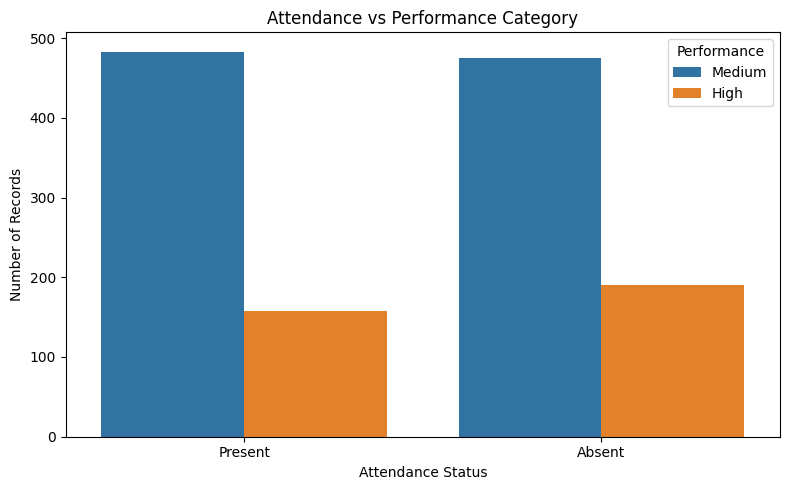

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='attendance', hue='categorize_performance')
plt.title('Attendance vs Performance Category')
plt.xlabel('Attendance Status')
plt.ylabel('Number of Records')
plt.legend(title='Performance')
plt.tight_layout()
plt.savefig('attendance_performance.png')
plt.show()

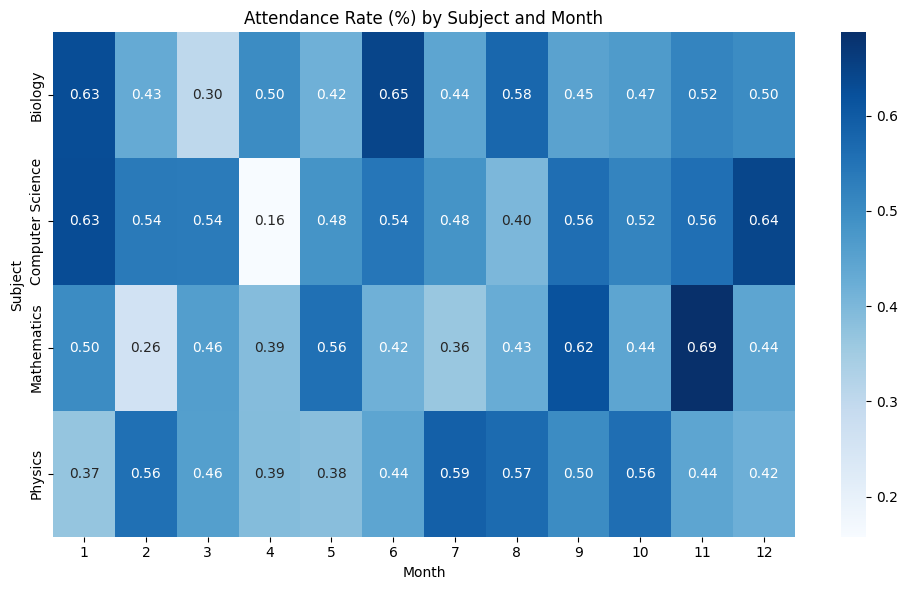

In [5]:
attendance_pivot = data.pivot_table(
    index='subject',
    columns='month',
    values='attendance',
    aggfunc=lambda x: (x == 'Present').sum() / len(x)  # % present
)

plt.figure(figsize=(10, 6))
sns.heatmap(attendance_pivot, annot=True, cmap='Blues', fmt='.2f')
plt.title('Attendance Rate (%) by Subject and Month')
plt.ylabel('Subject')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('attendance_heatmap.png')
plt.show()

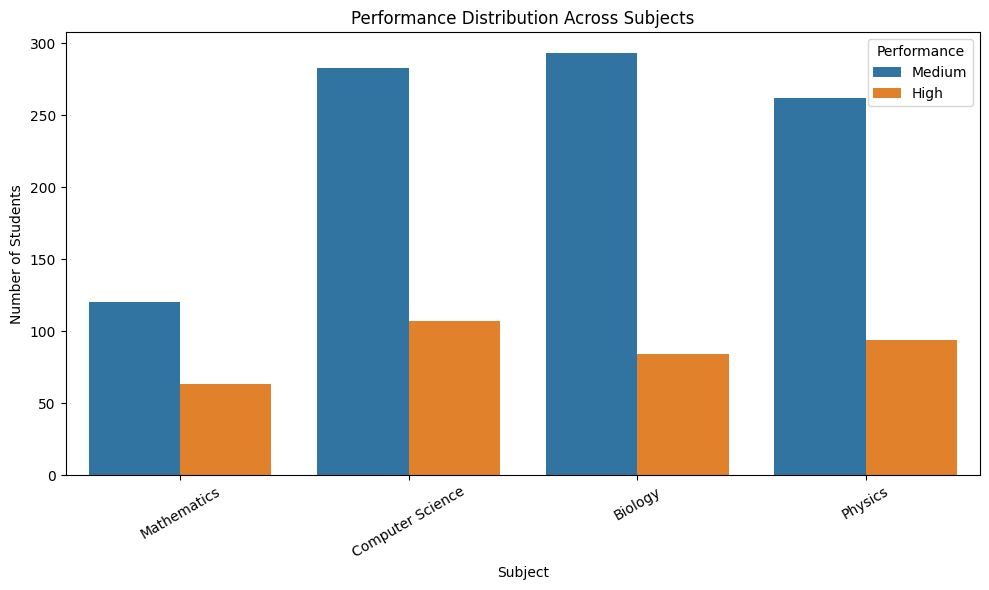

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='subject', hue='categorize_performance')
plt.title('Performance Distribution Across Subjects')
plt.xlabel('Subject')
plt.ylabel('Number of Students')
plt.xticks(rotation=30)
plt.legend(title='Performance')
plt.tight_layout()
plt.savefig('performance_by_subject.png')
plt.show()

In [7]:
data.head(50)

,student_id,name,subject,score,date,attendance,categorize_performance,year,month,year_month
0,1320,John,Mathematics,78.0,2021-02-27,Present,Medium,2021,2,2021-02
1,1327,Scott,Computer Science,74.0,2022-09-05,Present,Medium,2022,9,2022-09
2,1327,Todd,Computer Science,60.0,2022-09-19,Present,Medium,2022,9,2022-09
3,1327,Bryce,Computer Science,78.4,2024-09-11,Present,Medium,2024,9,2024-09
4,1055,Jessica,Biology,79.0,2020-06-21,Present,Medium,2020,6,2020-06
5,1055,Rachel,Biology,77.0,2024-02-18,Present,Medium,2024,2,2024-02
6,1055,Brittany,Biology,66.0,2021-01-18,Present,Medium,2021,1,2021-01
7,1055,Anthony,Biology,71.0,2023-05-18,Present,Medium,2023,5,2023-05
8,1262,Ann,Biology,78.4,2023-01-18,Present,Medium,2023,1,2023-01
9,1084,Dorothy,Computer Science,78.4,2024-08-20,Absent,Medium,2024,8,2024-08
